<a href="https://colab.research.google.com/github/AisyahFadhillah/Pemodelan-Simulasi-dan-Optimasi/blob/main/UTS_PSO_241061013_AISYAH_FADHILLAH_MUHAMMAD_AZIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
NAMA: AISYAH FADHILLAH MUHAMMAD AZIS

NIM: 241061013

MATA KULIAH: PEMODELAN SIMULASI DAN OPTIMASI

UJIAN TENGAH SEMESTER (UTS)

---


**Instruksi Tugas**
1. Download data UTS melalui link berikut (Data). Import data ke dalam Google Colab. Ganti
nama variabel menjadi Y, X1, X2, X3 dan X4 (point: 5)
2. Lakukan pemodelan regresi berganda dengan Y sebagai variabel dependen, interpretasikan
hasil pemodelan. (point: 15)
3. Selidiki distribusi probabilitas disetiap variabel (point: 5)
4. Carilah nilai parameter dari setiap distribusi probabilitas di Y, X1, X2, X3 dan X4 (point: 15)
5. Simulasikan Y, X1, X2, X3 dan X4 menjadi 500 data sesuai dengan aturan (point 25)
6. Modelkan data hasil simulasi dengan Y sebagai variabel dependen, dan interpretasikan (point
25).
7. Bandingkan pemodelan hasil simulasi dan tanpa simulasi, berikan penjelasan mengenai hasil.
(point 10)

#1. DOWNLOAD, IMPORT DATA & MENGGANTI VARIABEL

In [18]:
# MENGIMPORT LIBRARY
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

In [19]:
# UPLOAD FILE
from google.colab import files
uploaded = files.upload()

Saving data soal UTS.xlsx to data soal UTS (2).xlsx


In [20]:
# BACA FILE EXCEL
df = pd.read_excel('data soal UTS.xlsx')

# LIHAT DATA AWAL
df.head()

,IPM (Y),Mayoritas Lulusan (X1),Harapan Lama Sekolah (X2),APS (X3),AHH (X4)
0,71.28,0,12.53,56.90,71.11
1,73.80,1,13.62,71.40,69.55
2,70.25,0,13.00,71.43,67.85
3,73.64,0,13.43,74.53,68.84
4,75.11,1,13.87,79.24,71.34


In [21]:
# RENAME KOLOM (MENGGANTI NAMA VARIABEL MENJADI Y, X1, X2, X3, X4)
df.columns = ['Y', 'X1', 'X2', 'X3', 'X4']

df.head()

,Y,X1,X2,X3,X4
0,71.28,0,12.53,56.90,71.11
1,73.80,1,13.62,71.40,69.55
2,70.25,0,13.00,71.43,67.85
3,73.64,0,13.43,74.53,68.84
4,75.11,1,13.87,79.24,71.34


#2. PEMODELAN REGRESI BERGANDA

In [22]:
# DEFINISIKAN VARIABEL
X = df[['X1', 'X2', 'X3', 'X4']]
Y = df['Y']

# TAMBAHKAN KONSTANTA
X = sm.add_constant(X)

# MODEL REGRESI
model = sm.OLS(Y, X).fit()

# RINGKASAN HASIL
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     36.07
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           9.24e-05
Time:                        02:47:28   Log-Likelihood:                -16.957
No. Observations:                  12   AIC:                             43.91
Df Residuals:                       7   BIC:                             46.34
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         27.9539     30.443      0.918      0.3

Model regresi ini signifikan dan sangat kuat (R² = 0,954), tetapi dari semua variabel, hanya X2 yang benar-benar berpengaruh terhadap Y karena signifikan secara statistik. Variabel lain (X1, X3, X4) tidak terbukti berpengaruh. Kesimpulannya, perubahan Y dalam model ini terutama ditentukan oleh X2.

#3. DISTRIBUSI PPROBABILITAS SETIAP VARIABEL

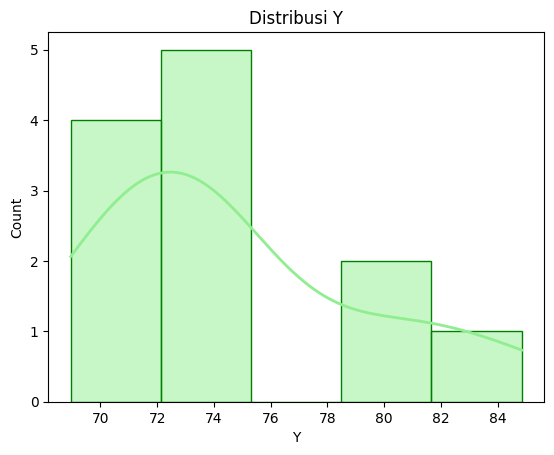

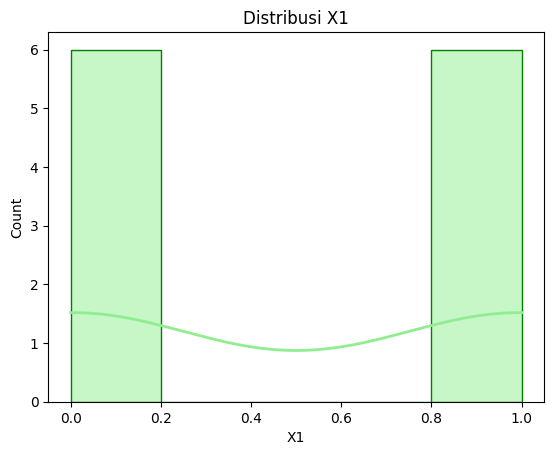

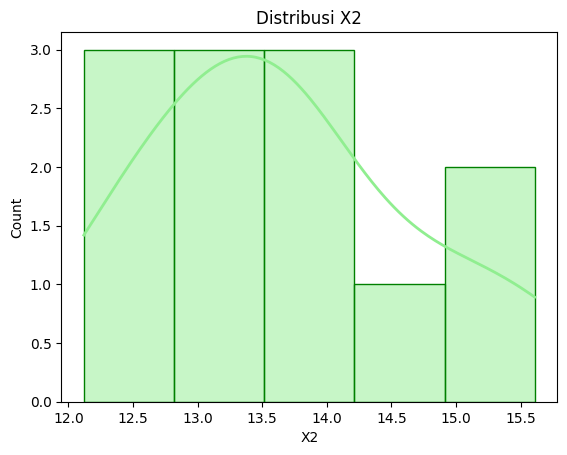

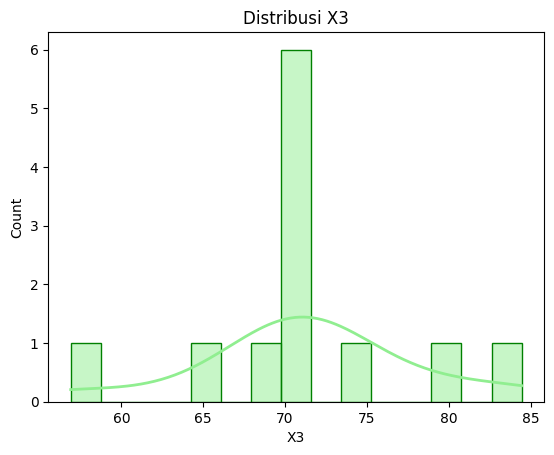

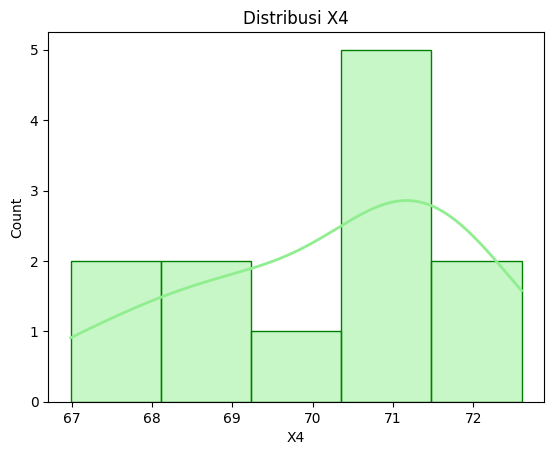

In [23]:
# HISTOGRAM + KDE
for col in df.columns:
    plt.figure()
    sns.histplot(
        df[col],
        kde=True,
        color='lightgreen',
        edgecolor='green',
        line_kws={'color': 'darkgreen', 'linewidth': 2}
    )
    plt.title(f'Distribusi {col}')
    plt.show()

In [24]:
# UJI NORMALITAS (SHAPIRO-WILK)
for col in df.columns:
    stat, p = stats.shapiro(df[col])
    print(f'{col}: p-value = {p}')

Y: p-value = 0.10163127996133225
X1: p-value = 0.0002883993735306056
X2: p-value = 0.7685364012361229
X3: p-value = 0.21855737319951896
X4: p-value = 0.39166265745653167


Sebagian besar variabel (Y, X2, X3, X4) mengikuti distribusi normal, sedangkan hanya X1 yang tidak normal. Hal ini menunjukkan bahwa secara umum data cukup memenuhi asumsi normalitas. Namun, perlu diperhatikan dalam analisis lanjutan.

#4. NILAI PARAMETER DARI SETIAP DISTRIBUSI PROBABILITAS

In [25]:
params = {}

for col in df.columns:
    mean = np.mean(df[col])
    std = np.std(df[col])
    params[col] = (mean, std)
    print(f'{col} -> Mean: {mean}, Std: {std}')

Y -> Mean: 74.69833333333334, Std: 4.62175982596336
X1 -> Mean: 0.5, Std: 0.5
X2 -> Mean: 13.636666666666665, Std: 0.9953921616908359
X3 -> Mean: 71.33999999999999, Std: 6.4355743074465925
X4 -> Mean: 70.19833333333334, Std: 1.6421674363136334


#5. MODEL SIMULASI Y, X1, X2, X3, X4 (500 OBSERVASI)

In [26]:
sim_data = pd.DataFrame()

for col in df.columns:
    mean, std = params[col]
    sim_data[col] = np.random.normal(mean, std, 500)

sim_data.head()

,Y,X1,X2,X3,X4
0,70.354370,0.851687,13.398904,59.932375,71.809578
1,65.537959,0.770113,10.868810,59.956993,69.355000
2,69.636939,0.828307,13.892324,58.456828,69.161652
3,76.407796,0.506958,13.999712,72.850590,68.923164
4,73.052772,0.813756,12.908230,77.635506,71.767824


#6. REGRESI DATA SIMULASI

In [27]:
X_sim = sim_data[['X1', 'X2', 'X3', 'X4']]
Y_sim = sim_data['Y']

X_sim = sm.add_constant(X_sim)

model_sim = sm.OLS(Y_sim, X_sim).fit()

print(model_sim.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.006
Method:                 Least Squares   F-statistic:                    0.2692
Date:                Wed, 15 Apr 2026   Prob (F-statistic):              0.898
Time:                        02:47:46   Log-Likelihood:                -1477.0
No. Observations:                 500   AIC:                             2964.
Df Residuals:                     495   BIC:                             2985.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         76.3555      9.722      7.854      0.0

Model regresi pada data simulasi tidak signifikan (Prob F > 0,05) dengan R² sangat kecil (0,003), sehingga variabel X1-X4 tidak mampu menjelaskan Y. Semua variabel juga tidak signifikan secara parsial. Kesimpulannya, pada data simulasi tidak terdapat hubungan yang berarti antara variabel terhadap Y.

#7. PERBANDINGAN PEMODELAN HASIL SIMULASI DAN TANPA SIMULASI

In [28]:
# AMBIL R-SQUARED
print("R-squared Data Asli:", model.rsquared)
print("R-squared Data Simulasi:", model_sim.rsquared)

# KOEFISIEN
print("\nKoefisien Data Asli:\n", model.params)
print("\nKoefisien Data Simulasi:\n", model_sim.params)

R-squared Data Asli: 0.9537286759929409
R-squared Data Simulasi: 0.00217056036989427

Koefisien Data Asli:
 const    27.953911
X1        0.812356
X2        4.868357
X3       -0.133418
X4       -0.150030
dtype: float64

Koefisien Data Simulasi:
 const    76.355535
X1       -0.134610
X2       -0.210591
X3       -0.002995
X4        0.021648
dtype: float64


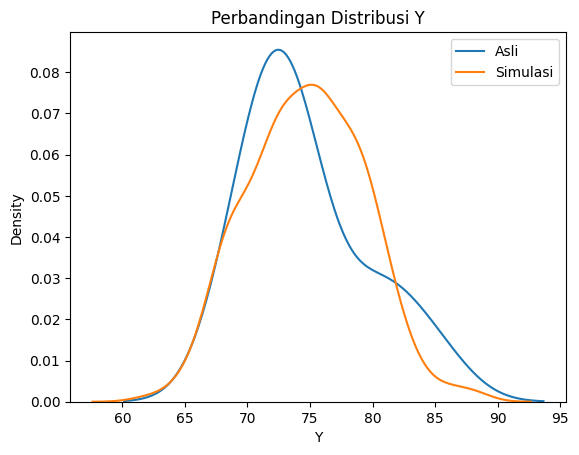

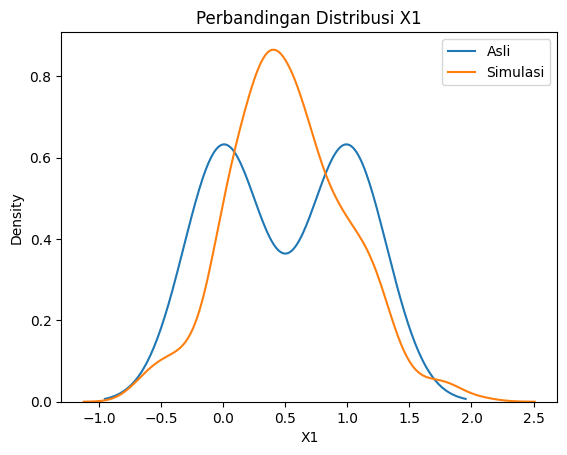

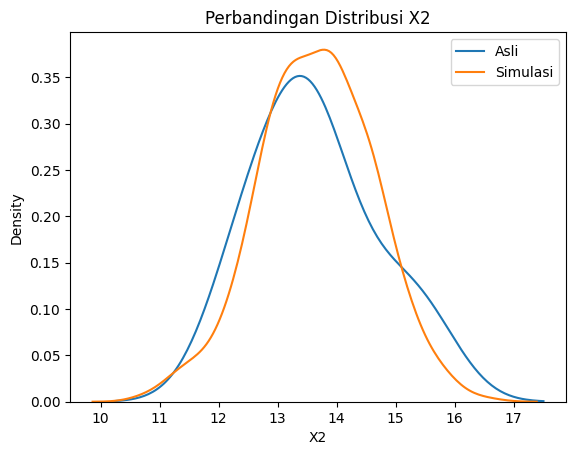

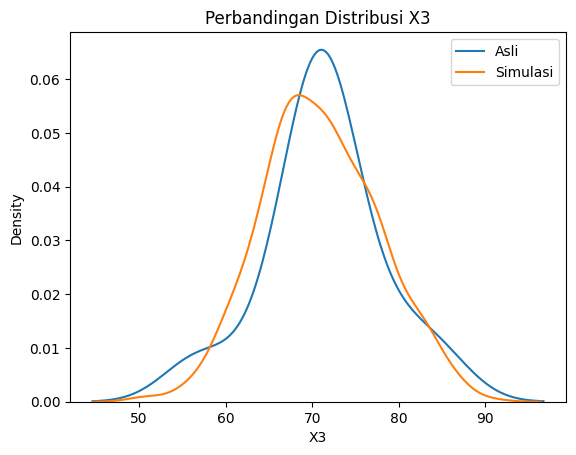

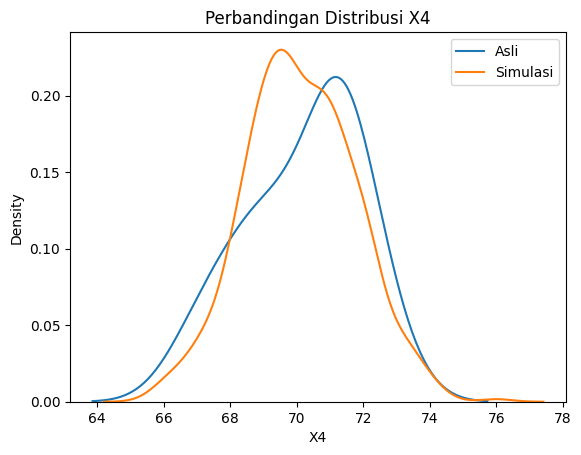

In [29]:
# BANDINGKAN DISTTRIBUSI ASLI VS SIMULASI
for col in df.columns:
    plt.figure()
    sns.kdeplot(df[col], label='Asli')
    sns.kdeplot(sim_data[col], label='Simulasi')
    plt.title(f'Perbandingan Distribusi {col}')
    plt.legend()
    plt.show()

Data asli menunjukkan model yang kuat (R² tinggi) dengan pengaruh variabel yang jelas, terutama X2, sedangkan data simulasi menghasilkan model yang sangat lemah (R² rendah) dengan koefisien yang hampir tidak berarti. Artinya, hubungan antar variabel pada data asli tidak berhasil dipertahankan dalam simulasi, sehingga distribusi saja tidak cukup untuk merepresentasikan hubungan dalam model regresi.
